<a href="https://colab.research.google.com/github/nlp-llm/Engagement-Driven-Content-Generation-with-Large-Language-Models/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Title: Engagement-Driven Content Generation Using Large Language Models

#### Sahil Arora (SID:501098147 ), Email: s11arora@torontomu.ca

#### Aman kaushik (SID: 501214203), Email: aman.kaushik@torontomu.ca

#### Evgenia Silajev (SID: 501017502), Email: esilajev@torontomu.ca

In our network, users have opinions distributed across a range. Extreme messages—very high or very low sentiment—only align with a small subset of users, so they activate fewer nodes. Moderate messages, on the other hand, are closer to the average opinion, so they fall within the acceptance threshold for more users in the bounded confidence model. That’s why they propagate more widely and achieve higher engagement.

We did use a lightweight LLM like GPT-2 for generating candidate posts, but we did not perform full LLM training or PPO fine-tuning. The original paper uses large models and reinforcement learning, which require GPU resources. Running that setup on a CPU-only environment would be extremely slow and impractical. So instead, we used a simplified approach where we map generated text to a numerical signal using sentiment and optimize that signal. This allowed us to capture the core idea while keeping the system computationally efficient.


* Built a synthetic social network where each user has an opinion → to simulate real-world user diversity
* Generated candidate messages using GPT-2 → to mimic realistic content creation
* Converted text into a numerical signal using sentiment analysis → to make content measurable and usable in the model
* Applied a bounded confidence diffusion model → to simulate how messages spread based on opinion similarity
* Measured engagement as number of activated users → to quantify how effective each message is
* Performed best message search and PPO-style optimization → to find message values that maximize engagement
* Used a simplified approach instead of full LLM training → because the original method requires GPU, so we used a CPU-friendly design while preserving the core idea

# Introduction

### Problem Description

The problem addressed in this project is how to generate social media content that maximizes user engagement within a network. Different users hold different opinions, and not all content spreads equally well. The key challenge is to identify which type of generated content can influence the largest number of users when propagated through a social network.

### Context of the Problem

This problem is important because social media platforms, marketing campaigns, and public communication strategies rely heavily on user engagement. Higher engagement leads to increased visibility, influence, and impact. Understanding how content spreads through a network—and how it interacts with user opinions—can significantly improve communication effectiveness in real-world scenarios.

### Limitation About Other Approaches

Traditional content generation methods focus mainly on text quality, relevance, or sentiment. However, they do not consider the structure of social networks or how information propagates between users. These approaches ignore the fact that different users respond differently depending on their existing opinions and their position within the network, leading to suboptimal engagement outcomes.

### Solution

In this project, we implement a simplified engagement-driven content generation framework that integrates language generation, sentiment analysis, network diffusion, and optimization. A synthetic social network is constructed where each user is assigned an opinion value. Multiple candidate posts are generated using a lightweight language model, and each post is converted into a numerical signal using sentiment scoring.

The generated content is then injected into the network and propagated using a bounded-confidence diffusion model, where users are influenced only if the message aligns closely with their opinions. Engagement is measured by the number of activated users. We compare multiple generated posts, perform a search over possible message values, and apply a lightweight PPO-style optimization approach to iteratively improve the message for maximum engagement.

This approach moves beyond traditional text-based evaluation by incorporating network-aware dynamics, enabling the selection and optimization of content based on its ability to spread effectively through a social system.

# Background

Explain the related work using the following table

| Reference |Explanation |  Dataset/Input |Weakness
| --- | --- | --- | --- |
| Coppolillo et al. [1] (Engagement-Driven Content Generation with LLMs) |This method generates content using an LLM and evaluates it using a simulated social network. Engagement and fluency are used as reward signals to optimize content generation for maximum spread and influence.| Synthetic and real-world social networks (e.g., Brexit, Italian Referendum), prompts, node opinions, injection nodes | Computationally expensive and requires complex simulation and fine-tuning; future work can explore more realistic engagement models and scalable training methods

# Methodology
In this project, we implement a CPU-friendly simplified version of the engagement-driven content generation framework proposed by Coppolillo et al. Instead of reproducing the full large-scale reinforcement learning pipeline from the paper, we design a lightweight experimental system that preserves the core idea: content should be generated and selected based not only on textual quality, but also on its ability to spread through a social network and influence users.

Our method uses a synthetic social network dataset. First, a directed graph is created to represent a social network, where each node corresponds to a user and each edge represents a possible influence path. Each user is assigned an opinion value in the interval [0,1], where lower values represent more negative or resistant opinions and higher values represent more positive or receptive opinions.

Next, candidate posts are created using a small language model (gpt2) from a set of prompts. Each generated post is converted into a numeric signal using sentiment analysis. This sentiment score acts as the message value injected into the network. The message is then propagated through the graph using a simplified bounded-confidence diffusion rule: a user engages with the message if the difference between the user’s opinion and the message sentiment is below a fixed threshold. If engaged, the user’s opinion is partially updated toward the message, and the diffusion continues to neighboring nodes.

To evaluate engagement, we measure the total number of activated users after diffusion. We then compare multiple generated posts, search across candidate message values, and apply a lightweight PPO-style iterative optimization that gradually updates the message toward values that produce higher engagement. This does not implement full policy-gradient PPO training; instead, it provides a computationally feasible approximation of reinforcement learning suitable for CPU-only execution on a Mac.

The complete pipeline is:

Prompt → Generate candidate posts → Score sentiment → Inject message into graph → Simulate diffusion → Measure activated users → Select or optimize the best message


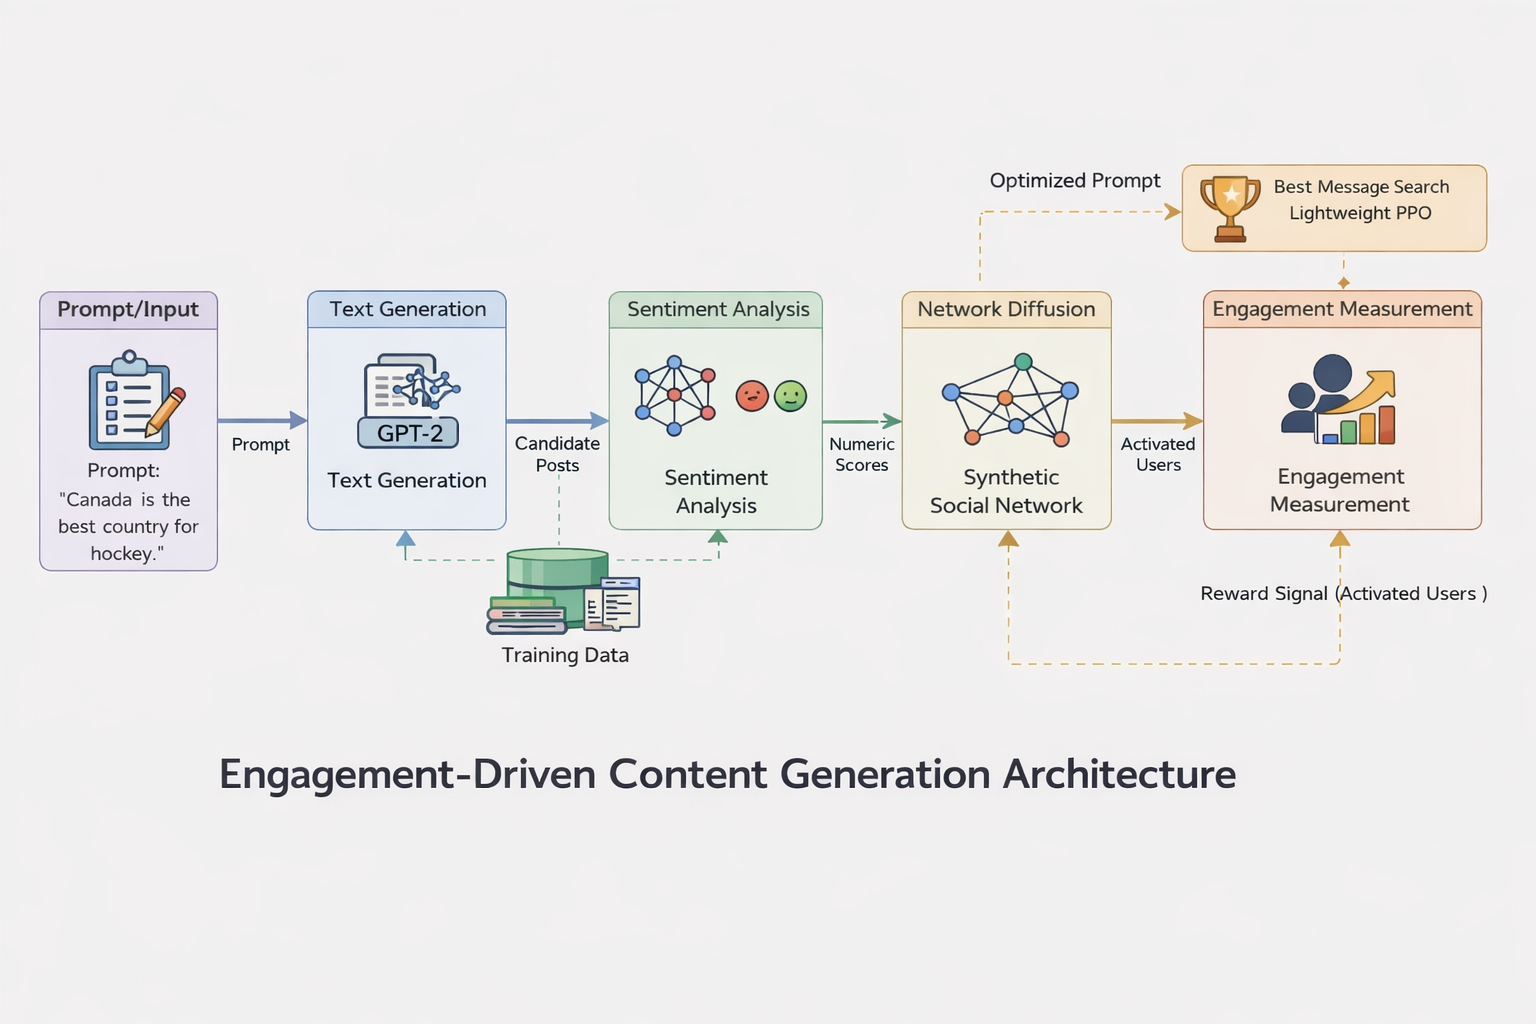

# Implementation

In this project, we implement a simplified engagement-driven content generation system that runs efficiently on a Mac without GPU support. The system includes four main components: social network generation, message generation, diffusion, and optimization.

A synthetic directed graph is created where each node represents a user with an opinion value between 0 and 1. Candidate posts are generated using a lightweight language model (gpt2) and converted into numerical values using sentiment analysis.

These message values are propagated through the network using a bounded-confidence diffusion model, where users are influenced only if the message aligns with their opinions. Engagement is measured by the number of activated users.

Finally, the system compares multiple messages, performs a search for the best message, and applies a lightweight PPO-style optimization to improve engagement. The graph is also visualized to illustrate how influence spreads across the network.

Main Execution

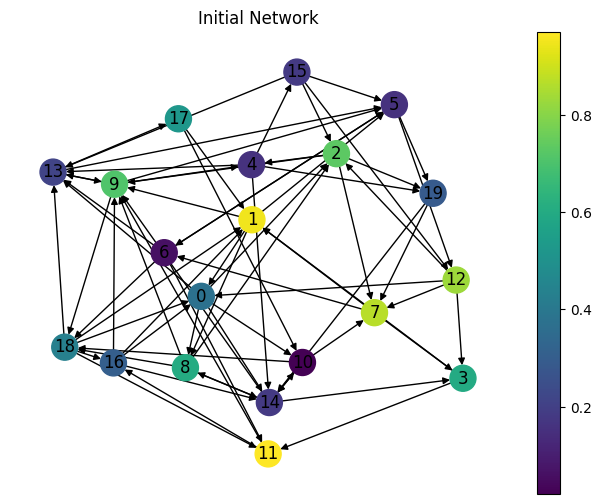

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Generated Posts and Their Results:
   Post Number                                          Post Text  \
0            1  Iran will win the war on terror," an Iranian e...   
1            2  Iran will win the war if its policy is to stop...   
2            3  Iran will win the war.\n\nSyria\n\nThe Islamic...   
3            4  Iran will win the war against Al Nusra when we...   
4            5  Iran will win the war if Russia does not coope...   

   Sentiment Score  Engagement Score  
0              1.0                 5  
1              0.0                 7  
2              1.0                 5  
3              0.0                 7  
4              0.0                 7  

Best Post (Post 2):
Text: Iran will win the war if its policy is to stop these wars," Lavrov said. "He said if the U.S. and its allies see that they are losing their air power, that they do not want any other means that would prevent them from expanding their military capabilities as much. In that way, this won't

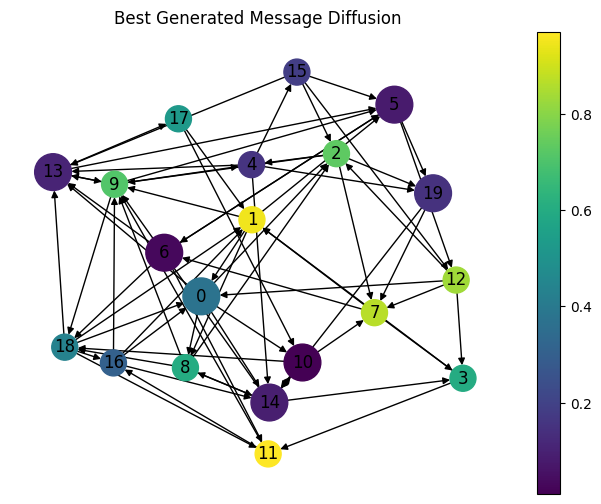


Best Message Value: 0.45
Best Engagement: 14


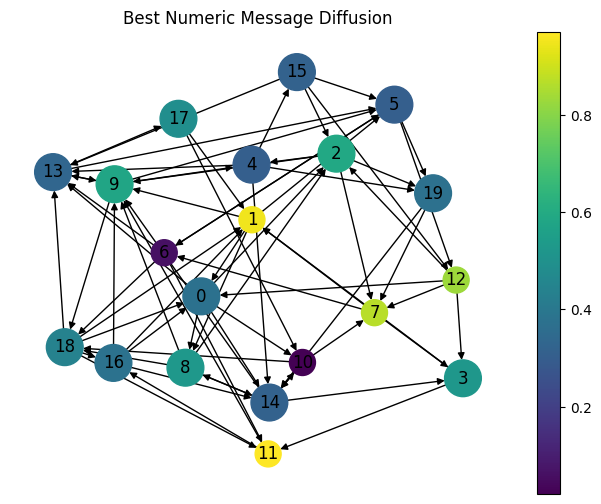

(0.4337969177607446, [(0.5895415141063362, 9), (0.4806896131591356, 11), (0.4806896131591356, 11), (0.4337969177607446, 14), (0.4337969177607446, 14), (0.4337969177607446, 14), (0.4337969177607446, 14), (0.4337969177607446, 14)])

PPO Optimization History:
[(0.025010755222666936, 7), (0.1418636200067911, 9), (0.1418636200067911, 9), (0.1418636200067911, 9), (0.22900844221693353, 10), (0.3219395004352519, 11), (0.3219395004352519, 11), (0.3204504435627057, 12)]


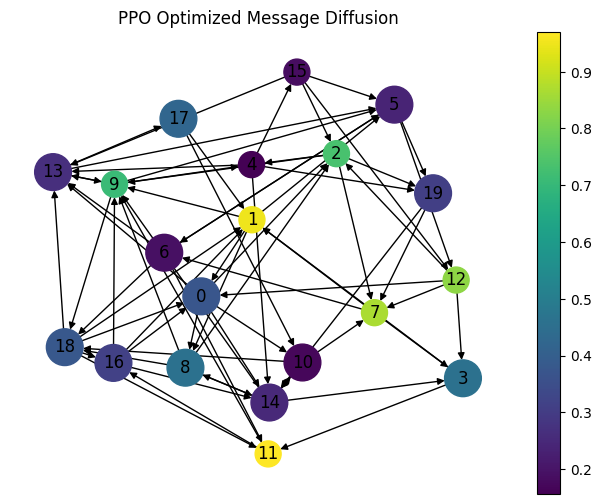

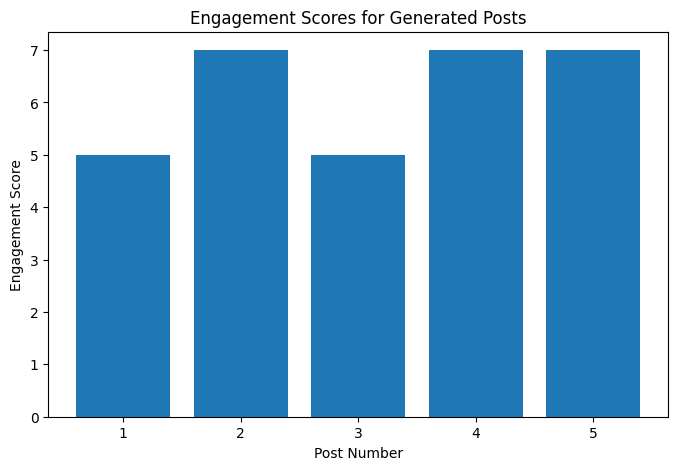

In [6]:

import sys, os
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath('../'))

from src.graph import create_graph
from src.visualization import plot_graph
from src.experiments import test_single_prompt, propagate
from src.optimization import search_best_message, lightweight_ppo

# Step 1: Create graph
G, opinions = create_graph()

# Step 2: Visualize
plot_graph(G, opinions, title='Initial Network')

# Step 3: User input for prompt
prompt = input("Enter your prompt for content generation: ")

# Generate multiple posts for the prompt
results_df = test_single_prompt(G, opinions, prompt, num_posts=5)

print("\nGenerated Posts and Their Results:")
print(results_df[["Post Number", "Post Text", "Sentiment Score", "Engagement Score"]])

# Find the best post
best_post_row = results_df.sort_values("Engagement Score", ascending=False).iloc[0]

print(f"\nBest Post (Post {best_post_row['Post Number']}):")
print(f"Text: {best_post_row['Post Text']}")
print(f"Sentiment: {best_post_row['Sentiment Score']}")
print(f"Engagement: {best_post_row['Engagement Score']}")

plot_graph(
    G,
    best_post_row["Updated Opinions"],
    activated_nodes=best_post_row["Activated Nodes"],
    title="Best Generated Message Diffusion"
)


# Step 4: Brute-force search
best_value, best_score, best_nodes, best_updated = search_best_message(G, opinions)

print("\nBest Message Value:", round(best_value, 3))
print("Best Engagement:", best_score)

plot_graph(
    G,
    best_updated,
    activated_nodes=best_nodes,
    title="Best Numeric Message Diffusion"
)

# Step 5: PPO optimization
print(lightweight_ppo(G, opinions))

ppo_message, ppo_history = lightweight_ppo(G, opinions)

print("\nPPO Optimization History:")
print(ppo_history)

ppo_score, ppo_updated, ppo_nodes = propagate(G, opinions, ppo_message)

plot_graph(
    G,
    ppo_updated,
    activated_nodes=ppo_nodes,
    title="PPO Optimized Message Diffusion"
)

plt.figure(figsize=(8, 5))
plt.bar(results_df["Post Number"].astype(str), results_df["Engagement Score"])
plt.xlabel("Post Number")
plt.ylabel("Engagement Score")
plt.title("Engagement Scores for Generated Posts")
plt.show()

![Comparison: Original Paper vs Our Project](comparison_original_vs_our_project.png)

*Comparison: Original Paper vs Our Project*

# Conclusion and Future Direction

In this project, we implemented a simplified engagement-driven content generation system using a synthetic social network and diffusion model. The results and graph visualization show that content effectiveness depends on how well the message aligns with user opinions and network structure. Messages closer to the overall opinion distribution activate more users and achieve higher engagement.

The main strength of this approach is that it captures network-aware content optimization in a computationally efficient way. However, the model has limitations, including the use of synthetic data, simplified sentiment scoring, and a lightweight approximation of reinforcement learning.

In future work, this system can be improved by using real-world datasets, more advanced language models, and full reinforcement learning methods. Additional enhancements could include modeling dynamic user behavior and more realistic engagement metrics.

# References:

[1]: Erica Coppolillo, Federico Cinus, Marco Minici, Francesco Bonchi, and Giuseppe Manco, Engagement-Driven Content Generation with Large Language Models, Proceedings of the 31st ACM SIGKDD Conference on Knowledge Discovery and Data Mining (KDD), 2025.

